In [50]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [17]:
con = duckdb.connect("../db/songs.duckdb", read_only=False)

In [31]:
## test query 1 to confirm connection and data loading

df = con.execute("""SELECT energy, track_popularity, tempo, track_name, track_artist, liveness FROM songs WHERE liveness > .7 ORDER BY liveness DESC""").fetchdf()

df.head(10)

,energy,track_popularity,tempo,track_name,track_artist,liveness
0,0.891,50,147.509,Knockin' On Heaven's Door - Live In London / 1992,Guns N' Roses,0.996
1,0.883,15,120.953,It Doesn't Matter,Firefall,0.994
2,0.929,50,134.186,Sweet Child O' Mine - Live In Paris / 1992,Guns N' Roses,0.992
3,0.815,32,127.035,My Love (Live),Humming House,0.991
4,0.844,3,100.227,Persiana Americana,Soda Stereo,0.991
5,0.707,53,132.211,Vivir Sin Aire - Unplugged,Maná,0.990
6,0.973,35,159.054,Move To The City - Live In Japan / 1992,Guns N' Roses,0.990
7,0.755,0,150.143,Disco Eterno,Soda Stereo,0.990
8,0.823,19,130.518,5 8 6 - Live,New Order,0.988
9,0.940,32,146.595,Dreams - Live,Van Halen,0.988


In [ ]:
## top 15 most popular songs in list (distinct needed as there are duplicates)

df = con.execute("""SELECT DISTINCT track_name, track_artist, track_popularity FROM songs ORDER BY track_popularity DESC LIMIT 15""").fetchdf()
df.head(15)

,track_name,track_artist,track_popularity
0,Dance Monkey,Tones and I,100
1,ROXANNE,Arizona Zervas,99
2,The Box,Roddy Ricch,98
3,Circles,Post Malone,98
4,Memories,Maroon 5,98
5,Tusa,KAROL G,98
6,Blinding Lights,The Weeknd,98
7,everything i wanted,Billie Eilish,97
8,Falling,Trevor Daniel,97
9,Don't Start Now,Dua Lipa,97


In [ ]:
## there are duplicates BECAUSE each song is in a different playlist.

df = con.execute("""SELECT track_name, track_artist, track_id, track_popularity FROM songs ORDER BY track_popularity DESC""").fetchdf()

df.head(10)

,track_name,track_artist,track_id,track_popularity
0,Dance Monkey,Tones and I,2XU0oxnq2qxCpomAAuJY8K,100
1,Dance Monkey,Tones and I,2XU0oxnq2qxCpomAAuJY8K,100
2,ROXANNE,Arizona Zervas,696DnlkuDOXcMAnKlTgXXK,99
3,ROXANNE,Arizona Zervas,696DnlkuDOXcMAnKlTgXXK,99
4,ROXANNE,Arizona Zervas,696DnlkuDOXcMAnKlTgXXK,99
5,ROXANNE,Arizona Zervas,696DnlkuDOXcMAnKlTgXXK,99
6,Tusa,KAROL G,7k4t7uLgtOxPwTpFmtJNTY,98
7,Memories,Maroon 5,2b8fOow8UzyDFAE27YhOZM,98
8,Blinding Lights,The Weeknd,0sf12qNH5qcw8qpgymFOqD,98
9,Memories,Maroon 5,2b8fOow8UzyDFAE27YhOZM,98


In [44]:
## remove ALL duplicates and keep only 1 version of each song because we don't care about the playlists for this analysis

con.execute("""CREATE OR REPLACE TABLE songs_deduped AS
                 SELECT * FROM (
                    SELECT *, ROW_NUMBER() OVER (PARTITION BY track_id ORDER BY track_id) AS rn
                    FROM songs
                 )
                 WHERE rn = 1""")



In [ ]:
## view number of songs in each table in the database to confirm deduplication worked

df = con.execute("""SELECT COUNT(*) AS count FROM songs""").fetchdf()
print("Number of songs in original table:")
print(df.head(10))

df = con.execute("""SELECT COUNT(*) AS count FROM songs_deduped""").fetchdf()
print("Number of songs in deduped table:")
print(df.head(10))


Number of songs in original table:
   count
0  32833
Number of songs in deduped table:
   count
0  28356


In [46]:
## double check the duplicates removed from cell [43]

df = con.execute("""SELECT track_name, track_artist, track_id, track_popularity FROM songs ORDER BY track_popularity DESC""").fetchdf()
print("Original songs table:")
print(df.head(10))

df = con.execute("""SELECT track_name, track_artist, track_id, track_popularity FROM songs_deduped ORDER BY track_popularity DESC""").fetchdf()
print("Deduped songs table:")
print(df.head(10))


Original songs table:
        track_name    track_artist                track_id  track_popularity
0     Dance Monkey     Tones and I  2XU0oxnq2qxCpomAAuJY8K               100
1     Dance Monkey     Tones and I  2XU0oxnq2qxCpomAAuJY8K               100
2          ROXANNE  Arizona Zervas  696DnlkuDOXcMAnKlTgXXK                99
3          ROXANNE  Arizona Zervas  696DnlkuDOXcMAnKlTgXXK                99
4          ROXANNE  Arizona Zervas  696DnlkuDOXcMAnKlTgXXK                99
5          ROXANNE  Arizona Zervas  696DnlkuDOXcMAnKlTgXXK                99
6             Tusa         KAROL G  7k4t7uLgtOxPwTpFmtJNTY                98
7         Memories        Maroon 5  2b8fOow8UzyDFAE27YhOZM                98
8  Blinding Lights      The Weeknd  0sf12qNH5qcw8qpgymFOqD                98
9         Memories        Maroon 5  2b8fOow8UzyDFAE27YhOZM                98
Deduped songs table:
            track_name    track_artist                track_id  \
0         Dance Monkey     Tones and I  2XU0

In [ ]:
## now we will use songs_deduped for all future analysis to avoid duplicates skewing results 

corr_with_popularity = con.execute("""SELECT 
    corr(energy, track_popularity) AS energy_corr,
    corr(danceability, track_popularity) AS danceability_corr,
    corr(speechiness, track_popularity) AS speechiness_corr,
    corr(acousticness, track_popularity) AS acousticness_corr,
    corr(instrumentalness, track_popularity) AS instrumentalness_corr,
    corr(liveness, track_popularity) AS liveness_corr,
    corr(valence, track_popularity) AS valence_corr,
    corr(tempo, track_popularity) AS tempo_corr
FROM songs_deduped""").fetchdf()

print("Correlation of each feature with track popularity:")
print(corr_with_popularity)


Correlation of each feature with track popularity:
   energy_corr  danceability_corr  speechiness_corr  acousticness_corr  \
0    -0.103622           0.046597          0.005206           0.091725   

   instrumentalness_corr  liveness_corr  valence_corr  tempo_corr  
0              -0.124431      -0.052773      0.022581    0.004446  


In [48]:
## There are no values of significance |.3| or higher
## But values greater than |.05|...
## energy: -.104
## acousticness: .092
## instrumentalness: -.124
## liveness: -.053


df = con.execute("""SELECT 
    energy, danceability, speechiness, acousticness, instrumentalness, liveness, valence, tempo,
    track_popularity FROM songs_deduped""").fetchdf()

corr_matrix = df.corr(numeric_only=True)
print("Correlation matrix of all features with each other and with track popularity:")
print(corr_matrix)

Correlation matrix of all features with each other and with track popularity:
                    energy  danceability  speechiness  acousticness  \
energy            1.000000     -0.081436    -0.029008     -0.545886   
danceability     -0.081436      1.000000     0.183453     -0.028878   
speechiness      -0.029008      0.183453     1.000000      0.024945   
acousticness     -0.545886     -0.028878     0.024945      1.000000   
instrumentalness  0.023818     -0.002267    -0.107959     -0.003101   
liveness          0.163709     -0.127002     0.059343     -0.074540   
valence           0.149710      0.333729     0.064701     -0.018999   
tempo             0.151545     -0.184575     0.032729     -0.114335   
track_popularity -0.103622      0.046597     0.005206      0.091725   

                  instrumentalness  liveness   valence     tempo  \
energy                    0.023818  0.163709  0.149710  0.151545   
danceability             -0.002267 -0.127002  0.333729 -0.184575   
speechi

                    energy  danceability  speechiness  acousticness  \
energy                 NaN           NaN          NaN     -0.545886   
danceability           NaN           NaN     0.183453           NaN   
speechiness            NaN      0.183453          NaN           NaN   
acousticness     -0.545886           NaN          NaN           NaN   
instrumentalness       NaN           NaN    -0.107959           NaN   
liveness          0.163709     -0.127002          NaN           NaN   
valence           0.149710      0.333729          NaN           NaN   
tempo             0.151545     -0.184575          NaN     -0.114335   
track_popularity -0.103622           NaN          NaN           NaN   

                  instrumentalness  liveness   valence     tempo  \
energy                         NaN  0.163709  0.149710  0.151545   
danceability                   NaN -0.127002  0.333729 -0.184575   
speechiness              -0.107959       NaN       NaN       NaN   
acousticness     

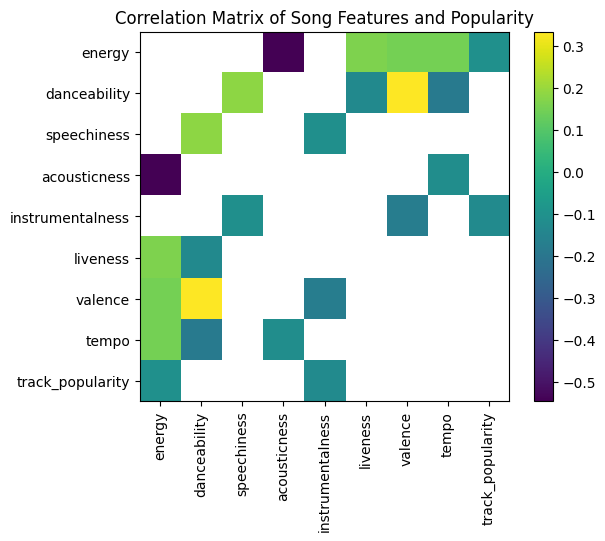

In [56]:
## significant results greater than |.3|

## energy and acousticness:     -.546
## danceability and valence:    .334


## slight significant results greater than |.1|


df = con.execute("""SELECT 
    energy, danceability, speechiness, acousticness, instrumentalness, liveness, valence, tempo,
    track_popularity FROM songs_deduped""").fetchdf()

corr_matrix = df.corr(numeric_only=True)
filtered = corr_matrix.where((np.abs(corr_matrix) > 0.1) & (corr_matrix != 1.0))

print(filtered)

plt.imshow(filtered)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix of Song Features and Popularity")
plt.show()


In [ ]:
## what do the correlations tell us?

## there is a very slight weak correlation between energy and popularity, but overall popularity
## does not seem to matter with any song features

## danceability and valence are positively correlated, 
## which makes sense because both are related to how "happy" or "positive" a song is

## energy and acousticness are negatively correlated, 
## which also makes sense because more energetic songs tend to be less acoustic and more electric

In [65]:
## Recall our goal -- what makes a song popular?

# Let's take a look at how our dataset represents popularity.

## let's define a threshold for a popular song... let's say ~20,000,000 streams on spotify.
## this corresponds to a track_popularity of around 5 in our dataset, so we will use that as our threshold for popularity.


popular = con.execute("""SELECT COUNT(*) AS popular FROM songs_deduped where track_popularity > 5""").fetchdf()

not_popular = con.execute("""SELECT COUNT(*) AS non_popular FROM songs_deduped where track_popularity <= 5""").fetchdf()

print(popular)
print(not_popular)



   popular
0    24077
   non_popular
0         4279


                    energy  danceability  speechiness  acousticness  \
energy                 NaN           NaN          NaN     -0.546235   
danceability           NaN           NaN     0.190882           NaN   
speechiness            NaN      0.190882          NaN           NaN   
acousticness     -0.546235           NaN          NaN           NaN   
instrumentalness       NaN           NaN          NaN           NaN   
liveness          0.168718     -0.119476          NaN           NaN   
valence           0.157945      0.341614          NaN           NaN   
tempo             0.153115     -0.175950          NaN     -0.115736   
track_popularity       NaN           NaN          NaN           NaN   

                  instrumentalness  liveness   valence     tempo  \
energy                         NaN  0.168718  0.157945  0.153115   
danceability                   NaN -0.119476  0.341614 -0.175950   
speechiness                    NaN       NaN       NaN       NaN   
acousticness     

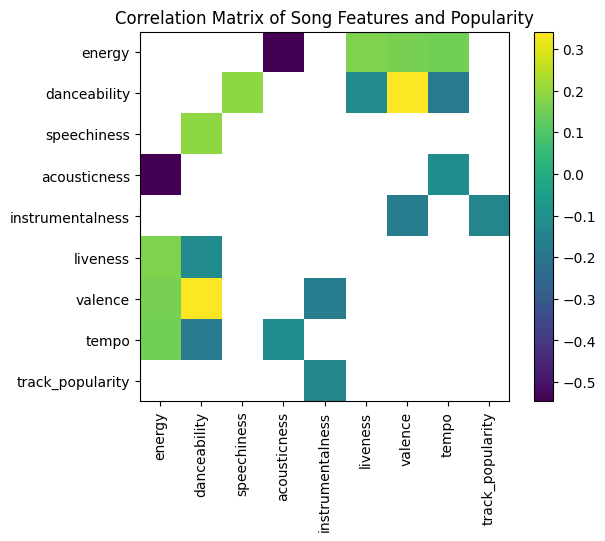

In [66]:
# now we will use this threshold to see if there are any obvious correlations among popular songs

df = con.execute("""SELECT 
    energy, danceability, speechiness, acousticness, instrumentalness, liveness, valence, tempo,
    track_popularity FROM songs_deduped WHERE track_popularity > 5""").fetchdf()

corr_matrix = df.corr(numeric_only=True)
filtered = corr_matrix.where((np.abs(corr_matrix) > 0.1) & (corr_matrix != 1.0))

print(filtered)

plt.imshow(filtered)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix of Song Features and Popularity")
plt.show()

                    energy  danceability  speechiness  acousticness  \
energy                 NaN           NaN          NaN     -0.529833   
danceability           NaN           NaN     0.143495           NaN   
speechiness            NaN      0.143495          NaN           NaN   
acousticness     -0.529833           NaN          NaN           NaN   
instrumentalness  0.112524           NaN    -0.153720           NaN   
liveness          0.127016     -0.158902          NaN           NaN   
valence           0.101567      0.294575          NaN           NaN   
tempo             0.144138     -0.234671          NaN     -0.106391   
track_popularity       NaN           NaN          NaN           NaN   

                  instrumentalness  liveness   valence     tempo  \
energy                    0.112524  0.127016  0.101567  0.144138   
danceability                   NaN -0.158902  0.294575 -0.234671   
speechiness              -0.153720       NaN       NaN       NaN   
acousticness     

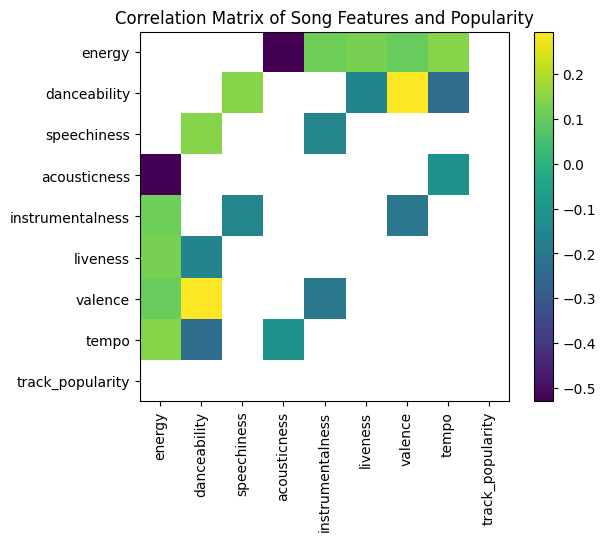

In [67]:
## hiw about non popular songs?

df = con.execute("""SELECT 
    energy, danceability, speechiness, acousticness, instrumentalness, liveness, valence, tempo,
    track_popularity FROM songs_deduped WHERE track_popularity <= 5""").fetchdf()

corr_matrix = df.corr(numeric_only=True)
filtered = corr_matrix.where((np.abs(corr_matrix) > 0.1) & (corr_matrix != 1.0))

print(filtered)

plt.imshow(filtered)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix of Song Features and Popularity")
plt.show()

In [ ]:
## Ok, not much difference between popular and non popular songs in terms of correlations between features. 

## We're going to have to dive deeper, but first, let's look at keys

df = con.execute("""SELECT key, AVG(track_popularity) as avg_popularity, COUNT(*) as count FROM songs_deduped WHERE track_popularity BETWEEN 5 AND 85 GROUP BY key""").fetchdf()

print(df)

## removed the most popular and least popular songs
## Key 8 (G#) the most popular 
# Key 7 (G) The least popular 

    key  avg_popularity  count
0     0       45.910762   2611
1     1       45.664283   2937
2     2       44.684310   2116
3     3       45.036765    680
4     4       45.552294   1635
5     5       46.005621   1957
6     6       45.057602   1927
7     7       43.989895   2474
8     8       46.956571   1773
9     9       45.935921   2216
10   10       45.904101   1658
11   11       45.521639   2172


In [ ]:
# Check popularity based on mode (major or minor)

# major = 1, minor = 0

df = con.execute("""SELECT mode, AVG(track_popularity) as avg_popularity, COUNT(*) as count FROM songs_deduped WHERE track_popularity BETWEEN 5 AND 85 GROUP BY mode""").fetchdf()
print(df)

   mode  avg_popularity  count
0     0       45.125729  10459
1     1       45.805213  13697


In [ ]:
# still no obvious trend in the data, so we need to get creative

df = con.execute("""
SELECT
    energy,
    danceability,
    speechiness,
    instrumentalness,
    acousticness,
    liveness,
    valence,
    tempo,
    track_popularity,
    playlist_genre
FROM songs_deduped
""").fetchdf()

df["energy_bin"] = pd.cut(df["energy"], bins=5)

energy_bins = (
    df.groupby("energy_bin")["track_popularity"]
      .mean()
      .reset_index()
)

print(energy_bins)


#higher energy songs are less popular on average

         energy_bin  track_popularity
0  (-0.000825, 0.2]         44.643836
1        (0.2, 0.4]         42.005931
2        (0.4, 0.6]         41.498415
3        (0.6, 0.8]         40.744285
4        (0.8, 1.0]         35.765929


In [88]:

df = con.execute("""
SELECT
    energy,
    danceability,
    speechiness,
    instrumentalness,
    acousticness,
    liveness,
    valence,
    tempo,
    track_popularity,
    playlist_genre
FROM songs_deduped
""").fetchdf()

for col in ["danceability", "speechiness", "instrumentalness", "acousticness", "liveness", "valence", "tempo" ]:
    df[f"{col}_bin"] = pd.cut(df[col], bins=5)
    
    result = (
        df.groupby(f"{col}_bin")["track_popularity"]
          .mean()
          .reset_index()
    )
    
    print(f"\n{col.upper()}:\n", result)


# danceability - more popular songs are either high danceability or low danceability, but not as popular in the middle
# speechiness - similar to danceability, but more linear
# instrumentalness - More popular with very low instrumentalness, but otherwise no correlation
# acousticness - less popular with low acousticness, but otherwise no correlation
# liveness - clear pattern that popularity decreases with increased liveness
# valence - songs with low valence are less popular, but otherwise no correlation
# tempo - songs with very low tempo are not popular at all, but otherwise no correlation





DANCEABILITY:
      danceability_bin  track_popularity
0  (-0.000983, 0.197]         41.597015
1      (0.197, 0.393]         37.753996
2       (0.393, 0.59]         38.572282
3       (0.59, 0.786]         39.052547
4      (0.786, 0.983]         41.513616

SPEECHINESS:
       speechiness_bin  track_popularity
0  (-0.000918, 0.184]         39.228328
1      (0.184, 0.367]         40.083232
2      (0.367, 0.551]         38.659341
3      (0.551, 0.734]         36.615385
4      (0.734, 0.918]         42.437500

INSTRUMENTALNESS:
   instrumentalness_bin  track_popularity
0   (-0.000994, 0.199]         40.483207
1       (0.199, 0.398]         32.143596
2       (0.398, 0.596]         31.387460
3       (0.596, 0.795]         30.452874
4       (0.795, 0.994]         32.048295

ACOUSTICNESS:
      acousticness_bin  track_popularity
0  (-0.000994, 0.199]         37.954643
1      (0.199, 0.398]         42.240950
2      (0.398, 0.596]         42.107546
3      (0.596, 0.795]         42.491994
4      

In [ ]:
## ok, now we are getting somewhere, but we still don't have a clear picture of what makes a song popular.
## let's look at the top and bottom most popular songs

top = df.nlargest(5000, "track_popularity")
bottom = df.nsmallest(5000, "track_popularity")

for col in ["energy", "danceability", "speechiness", "instrumentalness", "acousticness", "liveness", "valence", "tempo"]:
    print(f"\n{col}")
    print("Top:", top[col].mean())
    print("Bottom:", bottom[col].mean())


#Results:  
# energy - popular songs have slightly lower energy on average
# instrumentalness - popular songs have much lower instrumentalness on average
# acousticness - popular songs have slightly higher acousticness on average

# all other results are similar between popular and non popular songs


energy
Top: 0.67616294
Bottom: 0.7273743799999999

danceability
Top: 0.6647464200000001
Bottom: 0.6426828

speechiness
Top: 0.10703756
Bottom: 0.10772381999999998

instrumentalness
Top: 0.023639042043999997
Bottom: 0.11377606949

acousticness
Top: 0.19599213906
Bottom: 0.14504104317600003

liveness
Top: 0.17974454
Bottom: 0.202909412

valence
Top: 0.531487022
Bottom: 0.51419002

tempo
Top: 121.60601059999999
Bottom: 121.00442039999999


In [93]:
# let's check for genre specific trends

genre_corr = con.execute("""
SELECT
    playlist_genre,
    COUNT(*) as n,
    corr(energy, track_popularity) AS energy_corr,
    corr(danceability, track_popularity) AS danceability_corr,
    corr(speechiness, track_popularity) AS speechiness_corr,
    corr(acousticness, track_popularity) AS acousticness_corr,
    corr(instrumentalness, track_popularity) AS instrumentalness_corr,
    corr(liveness, track_popularity) AS liveness_corr,
    corr(valence, track_popularity) AS valence_corr,
    corr(tempo, track_popularity) AS tempo_corr
FROM songs_deduped
GROUP BY playlist_genre
HAVING COUNT(*) > 100
ORDER BY n DESC
""").fetchdf()

print(genre_corr)

  playlist_genre     n  energy_corr  danceability_corr  speechiness_corr  \
0            rap  5401    -0.121090           0.135193         -0.079095   
1            pop  5132    -0.055089           0.090581          0.090547   
2            edm  4877    -0.066819           0.008076          0.031386   
3            r&b  4504    -0.115466          -0.049950         -0.019923   
4           rock  4305    -0.048948           0.064328         -0.000836   
5          latin  4137    -0.095466           0.027097          0.027815   

   acousticness_corr  instrumentalness_corr  liveness_corr  valence_corr  \
0           0.076106               0.029739      -0.060401     -0.027110   
1           0.028953              -0.140999      -0.000314      0.020773   
2           0.156346              -0.156163       0.016143      0.090044   
3           0.097015              -0.062043      -0.060847     -0.129252   
4           0.004912              -0.098203      -0.101484     -0.008803   
5          

## GENRE SPECIFIC RESULTS: 

1. ENERGY IS NEGATIVE ACROSS THE BOARD
    Higher energy songs are CONFIRMED less popular for all represented genres

2. INSTRUMENTALNESS IS ALSO NEGATIVE ACROSS THE BOARD (except rap where it's basically 0)
    Songs with more vocals are more popular

3. DANCEABILITY IS GENRE SPECIFIC
    It's important for Rap and Pop 
    Mostly uncorrelational for the other genres

4. ACOUSTICNESS IS POSITIVE ACROSS THE BOARD
    Very important for EDM and Latin
    RnB and Rap see slightly positive correlations
    Pop and Rock are not really acoustic dependent 


Other takeaways (minor details)
1. High liveness still very slightly leans to less popularity, especially in rock
2. Speechiness factors in podcasts, so it's a bit odd to measure, but pop songs need more words,   
    while rap songs typically favor less words (confirmed by instrumentalness)
3. Valence (positivity of a track) is negatively correlated with RnB, and positively correlated with EDM, and irrelevant otherwise.

